# **Monte Carlo Control for Racetrack**


### **Assignment 5 - Reinforcement Learning - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

In [ ]:
# Racetrack — Exercise 5.12 (Sutton & Barto)
# On-policy Monte Carlo Control (ε-greedy), with path intersection + 0.1 noise
# and -1 reward per step (including crash/finish step).

from dataclasses import dataclass
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ----------------------------
# Grid cell types (0/1/2/3)
# ----------------------------
CELL_EDGE = 0
CELL_TRACK = 1
CELL_START_LINE = 2
CELL_FINISH_LINE = 3

# ----------------------------
# Defaults
# ----------------------------
DEFAULT_MAX_SPEED = 4        # components in {0,1,2,3,4}
DEFAULT_MIN_SPEED = 0
DEFAULT_NOISE_PROB = 0.1     # with prob 0.1, acceleration=(0,0)
DEFAULT_STEP_REWARD = -1
DEFAULT_GAMMA = 1.0

ACTIONS = [(ax, ay) for ax in (-1, 0, 1) for ay in (-1, 0, 1)]  # 3 x 3 = 9 actions


def line(x0: int, y0: int, x1: int, y1: int):
    """Integer grid traversal of the line from (x0,y0) to (x1,y1), inclusive."""
    points = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    x, y = x0, y0

    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x += sx
        if e2 < dx:
            err += dx
            y += sy
    return points


@dataclass
class RacetrackEnv:
    grid: np.ndarray
    max_vx: int = DEFAULT_MAX_SPEED
    min_vx: int = DEFAULT_MIN_SPEED
    max_vy: int = DEFAULT_MAX_SPEED
    min_vy: int = DEFAULT_MIN_SPEED
    noise_prob: float = DEFAULT_NOISE_PROB
    step_reward: int = DEFAULT_STEP_REWARD
    rng: np.random.Generator | None = None
    pos0: tuple[int, int] | None = None  # fixed start for demos

    def __post_init__(self):
        if self.rng is None:
            self.rng = np.random.default_rng()

        xs, ys = np.where(self.grid == CELL_START_LINE)
        self.start_positions = list(zip(xs.tolist(), ys.tolist()))
        if not self.start_positions:
            raise ValueError("No start line cells (CELL_START_LINE=2) found in grid.")

        self.position: tuple[int, int] | None = None
        self.velocity: tuple[int, int] = (0, 0)

    def reset(self):
        if self.pos0 is None:
            self.position = self.start_positions[self.rng.integers(0, len(self.start_positions))]
        else:
            self.position = self.pos0
        self.velocity = (0, 0)
        return self._get_state()

    def _get_state(self):
        x, y = self.position
        vx, vy = self.velocity
        return (x, y, vx, vy)

    def _is_start_cell(self, x: int, y: int) -> bool:
        return (
            0 <= x < self.grid.shape[0]
            and 0 <= y < self.grid.shape[1]
            and int(self.grid[x, y]) == CELL_START_LINE
        )

    def _cell_type(self, x: int, y: int) -> int:
        # outside grid counts as boundary
        if x < 0 or x >= self.grid.shape[0] or y < 0 or y >= self.grid.shape[1]:
            return CELL_EDGE
        return int(self.grid[x, y])

    def step(self, action: tuple[int, int], noise_on: bool = True):
        """
        Returns (reward, next_state, done).
        next_state is None when done=True (finish crossed).
        """
        assert self.position is not None, "Call reset() before step()."
        ax, ay = action

        # 0.1 noise: ignore intended action, apply (0,0)
        if noise_on and (self.rng.random() < self.noise_prob):
            ax, ay = 0, 0

        # update velocity
        vx, vy = self.velocity
        vx_p = int(np.clip(vx + ax, self.min_vx, self.max_vx))
        vy_p = int(np.clip(vy + ay, self.min_vy, self.max_vy))

        # (0,0) velocity not allowed except on start line
        x, y = self.position
        if (vx_p == 0 and vy_p == 0) and (not self._is_start_cell(x, y)):
            vx_p, vy_p = vx, vy

        # move (x=row downward, y=col rightward)
        x1 = x - vx_p
        y1 = y + vy_p

        # check the entire projected path
        for (px, py) in line(x, y, x1, y1)[1:]:
            ctype = self._cell_type(px, py)
            if ctype == CELL_FINISH_LINE:
                self.position = (px, py)
                self.velocity = (vx_p, vy_p)
                return self.step_reward, None, True
            if ctype == CELL_EDGE:
                # crash -> back to random start, v=(0,0), episode continues
                self.position = self.start_positions[self.rng.integers(0, len(self.start_positions))]
                self.velocity = (0, 0)
                return self.step_reward, self._get_state(), False

        # normal move
        self.position = (x1, y1)
        self.velocity = (vx_p, vy_p)
        return self.step_reward, self._get_state(), False


def epsilon_greedy_action(Q, state, epsilon: float, rng: np.random.Generator):
    if rng.random() < epsilon:
        return ACTIONS[int(rng.integers(0, len(ACTIONS)))]

    qs = np.array([Q[(state, a)] for a in ACTIONS], dtype=float)
    max_q = np.max(qs)
    best = np.where(qs == max_q)[0]
    return ACTIONS[int(best[rng.integers(0, len(best))])]


def generate_episode(env: RacetrackEnv, Q, epsilon: float, max_episode_length: int, noise_on: bool = True):
    states, actions, rewards = [], [], []
    s = env.reset()
    for _ in range(max_episode_length):
        a = epsilon_greedy_action(Q, s, epsilon, env.rng)
        r, s_next, done = env.step(a, noise_on=noise_on)
        states.append(s)
        actions.append(a)
        rewards.append(r)
        if done:
            break
        s = s_next
    return states, actions, rewards


def mc_control_on_policy(grid: np.ndarray,
                         epsilon: float = 0.1,
                         gamma: float = 1.0,
                         initial_Q: float = 0.0,
                         simulated_episodes: int = 50_000,
                         max_episode_length: int = 5_000,
                         seed: int | None = 0):
    rng = np.random.default_rng(seed)
    env = RacetrackEnv(grid=grid, rng=rng)

    Q = defaultdict(lambda: float(initial_Q))
    N = defaultdict(int)
    episode_lengths = []

    for _ in tqdm(range(simulated_episodes)):
        states, actions, rewards = generate_episode(env, Q, epsilon, max_episode_length, noise_on=True)
        episode_lengths.append(len(rewards))

        G = 0.0
        visited = set()  # first-visit

        for t in reversed(range(len(rewards))):
            s_t, a_t, r_t = states[t], actions[t], rewards[t]
            G = gamma * G + r_t

            key = (s_t, a_t)
            if key in visited:
                continue
            visited.add(key)

            N[key] += 1
            Q[key] += (G - Q[key]) / N[key]

    # greedy policy table pi[x,y,vx,vy] -> (ax,ay)
    rows, cols = grid.shape
    pi = np.zeros((rows, cols, DEFAULT_MAX_SPEED + 1, DEFAULT_MAX_SPEED + 1, 2), dtype=int)
    for x in range(rows):
        for y in range(cols):
            for vx in range(DEFAULT_MAX_SPEED + 1):
                for vy in range(DEFAULT_MAX_SPEED + 1):
                    s = (x, y, vx, vy)
                    qs = np.array([Q[(s, a)] for a in ACTIONS], dtype=float)
                    best_a = ACTIONS[int(np.argmax(qs))]
                    pi[x, y, vx, vy, 0] = best_a[0]
                    pi[x, y, vx, vy, 1] = best_a[1]

    return {"episode_lengths": episode_lengths, "Q": Q, "pi": pi}


def rollout_greedy_trajectory(grid: np.ndarray, pi: np.ndarray,
                             start_pos: tuple[int, int] | None = None,
                             max_steps: int = 10_000, seed: int | None = 123):
    rng = np.random.default_rng(seed)
    env = RacetrackEnv(grid=grid, rng=rng, pos0=start_pos)
    s = env.reset()
    path = [env.position]

    for _ in range(max_steps):
        x, y, vx, vy = s
        ax = int(pi[x, y, vx, vy, 0])
        ay = int(pi[x, y, vx, vy, 1])
        r, s_next, done = env.step((ax, ay), noise_on=False)
        path.append(env.position)
        if done:
            break
        s = s_next
    return path


def plot_track_with_paths(grid: np.ndarray, paths: list[list[tuple[int, int]]], title: str):
    plt.figure(figsize=(10, 6))
    plt.imshow(grid, interpolation="nearest")
    plt.gca().invert_yaxis()
    plt.title(title)
    for path in paths:
        xs = [p[1] for p in path]  # columns
        ys = [p[0] for p in path]  # rows
        plt.plot(xs, ys, marker="o", markersize=2, linewidth=1)
    plt.xlabel("y (col)")
    plt.ylabel("x (row)")
    plt.show()

100%|██████████| 50000/50000 [07:46<00:00, 107.22it/s]


Training finished.
Episodes: 50000
Last episode length: 88
Mean length (last 100): 113.7


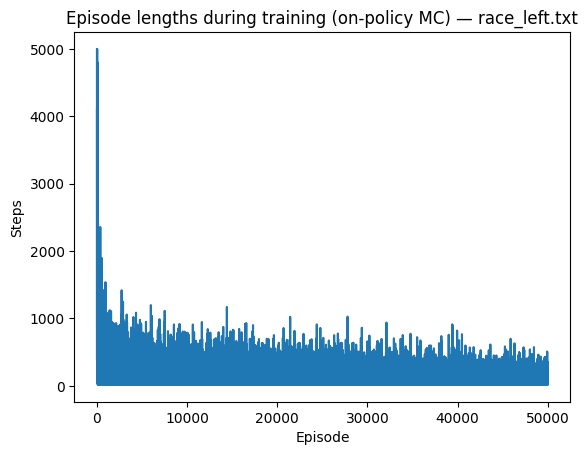

Start (np.int64(31), np.int64(7)) -> steps (noise OFF): 5000
Start (np.int64(31), np.int64(8)) -> steps (noise OFF): 5000
Start (np.int64(31), np.int64(6)) -> steps (noise OFF): 5000


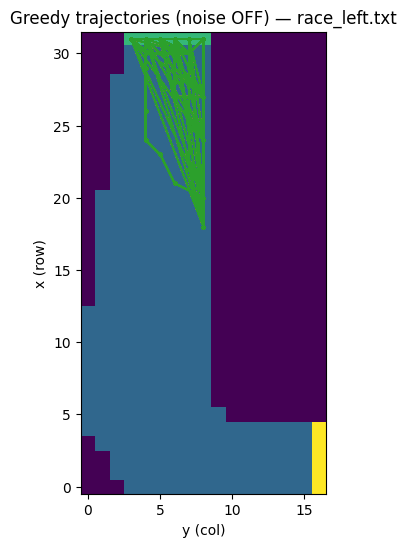

In [8]:
# =========================
# RUN TRAINING + DEMO PLOTS
# =========================
LAYOUT_PATH = "race_left.txt"
EPISODES = 50_000
MAX_EP_LEN = 5_000
EPSILON = 0.1
SEED = 0

grid = np.loadtxt(LAYOUT_PATH)

out = mc_control_on_policy(
    grid=grid,
    epsilon=EPSILON,
    gamma=1.0,
    initial_Q=0.0,
    simulated_episodes=EPISODES,
    max_episode_length=MAX_EP_LEN,
    seed=SEED
)

episode_lengths = out["episode_lengths"]
pi = out["pi"]

print("Training finished.")
print(f"Episodes: {len(episode_lengths)}")
print(f"Last episode length: {episode_lengths[-1]}")
print(f"Mean length (last 100): {np.mean(episode_lengths[-100:]):.1f}")

plt.figure()
plt.plot(episode_lengths)
plt.title(f"Episode lengths during training (on-policy MC) — {LAYOUT_PATH}")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Rollout 3 greedy trajectories from random start cells (noise OFF)
start_cells = list(zip(*np.where(grid == CELL_START_LINE)))
rng = np.random.default_rng(SEED)
chosen = [start_cells[i] for i in rng.choice(len(start_cells), size=min(3, len(start_cells)), replace=False)]

paths = []
for sp in chosen:
    path = rollout_greedy_trajectory(grid, pi, start_pos=sp, max_steps=5000, seed=SEED + 1)
    print(f"Start {sp} -> steps (noise OFF): {len(path) - 1}")
    paths.append(path)

plot_track_with_paths(grid, paths, title=f"Greedy trajectories (noise OFF) — {LAYOUT_PATH}")

  0%|          | 0/50000 [00:00<?, ?it/s]

100%|██████████| 50000/50000 [08:40<00:00, 95.98it/s] 


Training finished.
Episodes: 50000
Last episode length: 102
Mean length (last 100): 115.2


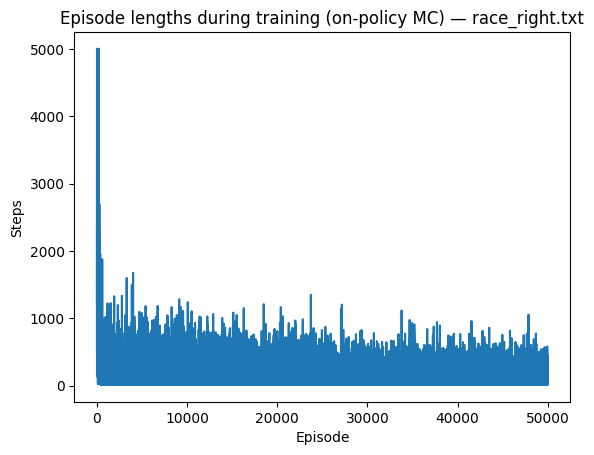

Start (np.int64(34), np.int64(11)) -> steps (noise OFF): 17
Start (np.int64(34), np.int64(10)) -> steps (noise OFF): 5000
Start (np.int64(34), np.int64(12)) -> steps (noise OFF): 5000


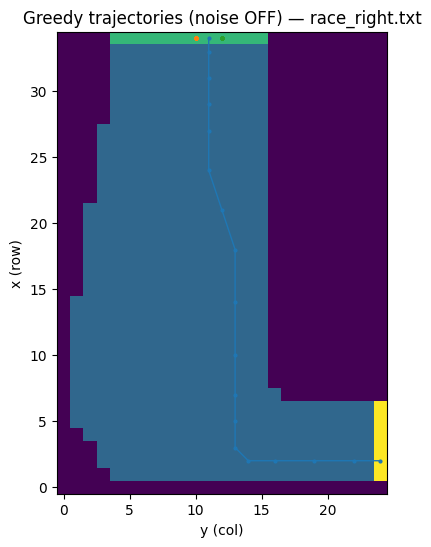

In [9]:
# =========================
# RUN TRAINING + DEMO PLOTS
# =========================
LAYOUT_PATH = "race_right.txt"
EPISODES = 50_000
MAX_EP_LEN = 5_000
EPSILON = 0.1
SEED = 0

grid = np.loadtxt(LAYOUT_PATH)

out = mc_control_on_policy(
    grid=grid,
    epsilon=EPSILON,
    gamma=1.0,
    initial_Q=0.0,
    simulated_episodes=EPISODES,
    max_episode_length=MAX_EP_LEN,
    seed=SEED
)

episode_lengths = out["episode_lengths"]
pi = out["pi"]

print("Training finished.")
print(f"Episodes: {len(episode_lengths)}")
print(f"Last episode length: {episode_lengths[-1]}")
print(f"Mean length (last 100): {np.mean(episode_lengths[-100:]):.1f}")

plt.figure()
plt.plot(episode_lengths)
plt.title(f"Episode lengths during training (on-policy MC) — {LAYOUT_PATH}")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Rollout 3 greedy trajectories from random start cells (noise OFF)
start_cells = list(zip(*np.where(grid == CELL_START_LINE)))
rng = np.random.default_rng(SEED)
chosen = [start_cells[i] for i in rng.choice(len(start_cells), size=min(3, len(start_cells)), replace=False)]

paths = []
for sp in chosen:
    path = rollout_greedy_trajectory(grid, pi, start_pos=sp, max_steps=5000, seed=SEED + 1)
    print(f"Start {sp} -> steps (noise OFF): {len(path) - 1}")
    paths.append(path)

plot_track_with_paths(grid, paths, title=f"Greedy trajectories (noise OFF) — {LAYOUT_PATH}")